## Imports

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import os

## Load all metric files

In [73]:
logistic = pd.read_csv("../results/logistic_regression_metrics.csv")

decision_tree = pd.read_csv("../results/decision_tree_metrics.csv")

random_forest = pd.read_csv("../results/random_forest_metrics.csv")

smote = pd.read_csv("../results/random_forest_smote_metrics.csv")

undersampling = pd.read_csv("../results/random_forest_random_undersampling_metrics.csv")

class_weights = pd.read_csv("../results/random_forest_class_weights_metrics.csv")

xgboost = pd.read_csv("../results/xgboost_metrics.csv")

xgboost_tuned = pd.read_csv("../results/xgboost_tuned_metrics.csv")

## Combine everything

In [74]:
comparison = pd.concat(
    [
        logistic,
        decision_tree,
        random_forest,
        smote,
        undersampling,
        class_weights,
        xgboost,
        xgboost_tuned
    ],
    ignore_index=True
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.978377,0.063272,0.863158,0.117901,0.950620
1,Decision Tree,0.997691,0.391566,0.684211,0.498084,0.841214
2,Random Forest,0.999436,0.898734,0.747368,0.816092,0.954520
3,Random Forest (SMOTE),0.978377,0.063272,0.863158,0.117901,0.950620
4,Random Forest (Random Undersampling),0.985603,0.092551,0.863158,0.167176,0.972907
5,Random Forest (Class Weights),0.999489,0.958333,0.726316,0.826347,0.943893
6,XGBoost,0.999366,0.810526,0.810526,0.810526,0.967861
7,Tuned XGBoost,0.999436,0.870588,0.778947,0.822222,0.968960


## Save master comparison

In [75]:
comparison.to_csv(
    "../results/final_model_comparison.csv",
    index=False
)

print("Comparison saved successfully.")

Comparison saved successfully.


## Sort by F1 Score

In [76]:
comparison = comparison.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest (Class Weights),0.999489,0.958333,0.726316,0.826347,0.943893
1,Tuned XGBoost,0.999436,0.870588,0.778947,0.822222,0.968960
2,Random Forest,0.999436,0.898734,0.747368,0.816092,0.954520
3,XGBoost,0.999366,0.810526,0.810526,0.810526,0.967861
4,Decision Tree,0.997691,0.391566,0.684211,0.498084,0.841214
5,Random Forest (Random Undersampling),0.985603,0.092551,0.863158,0.167176,0.972907
6,Logistic Regression,0.978377,0.063272,0.863158,0.117901,0.950620
7,Random Forest (SMOTE),0.978377,0.063272,0.863158,0.117901,0.950620


## Winner

In [77]:
winner = comparison.iloc[0]

print("="*60)

print("BEST MODEL")

print("="*60)

print(winner)

BEST MODEL
Model        Random Forest (Class Weights)
Accuracy                          0.999489
Precision                         0.958333
Recall                            0.726316
F1 Score                          0.826347
ROC-AUC                           0.943893
Name: 0, dtype: object


## Accuracy Comparison

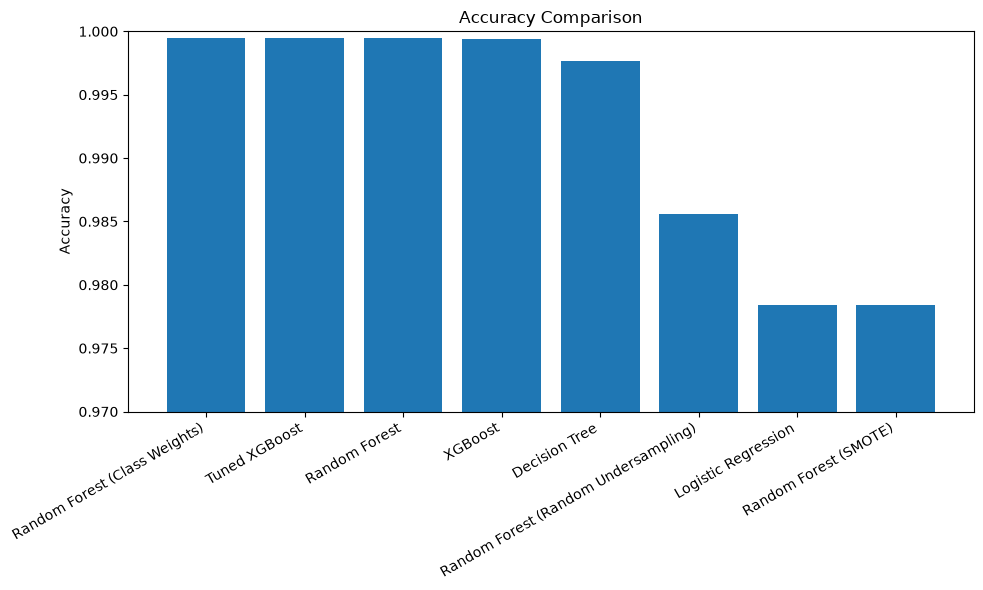

In [78]:
plt.figure(figsize=(10,6))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.ylim(0.97, 1.00)   # <-- Add this line here

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()
plt.show()

## Precision Comparison

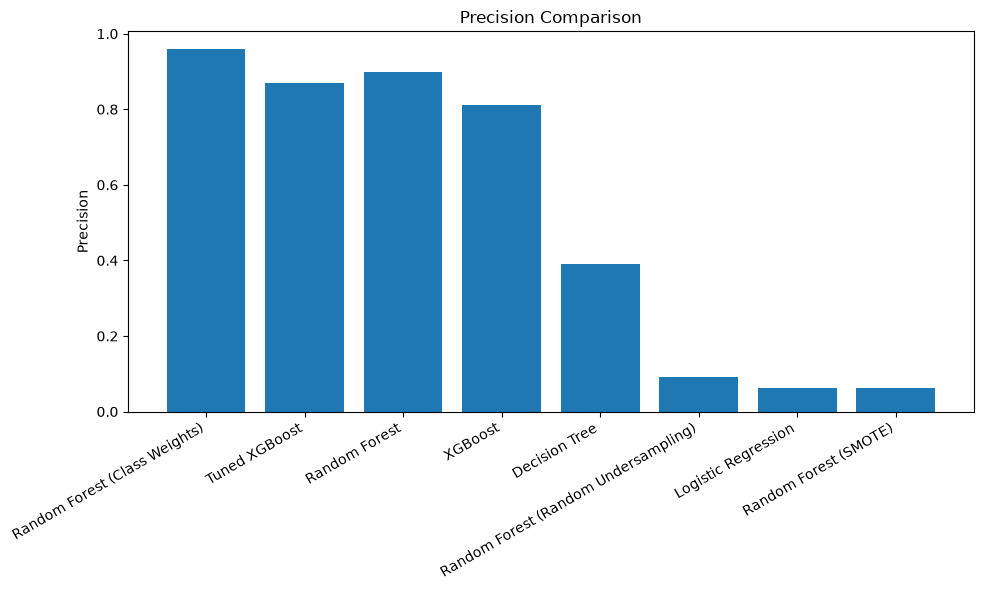

In [79]:
plt.figure(figsize=(10,6))

plt.bar(
    comparison["Model"],
    comparison["Precision"]
)

plt.xticks(rotation=30, ha="right")

plt.ylabel("Precision")

plt.title("Precision Comparison")

plt.tight_layout()

plt.savefig(
    "../artifacts/plots/model_precision_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Recall Comparison

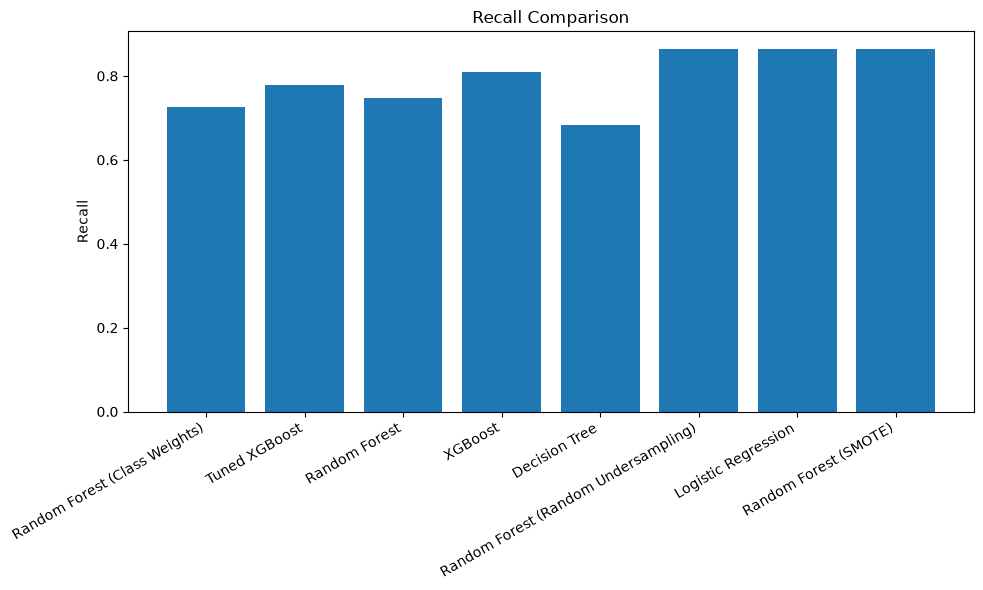

In [80]:
plt.figure(figsize=(10,6))

plt.bar(
    comparison["Model"],
    comparison["Recall"]
)

plt.xticks(rotation=30, ha="right")

plt.ylabel("Recall")

plt.title("Recall Comparison")

plt.tight_layout()

plt.savefig(
    "../artifacts/plots/model_recall_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## F1 Comparison

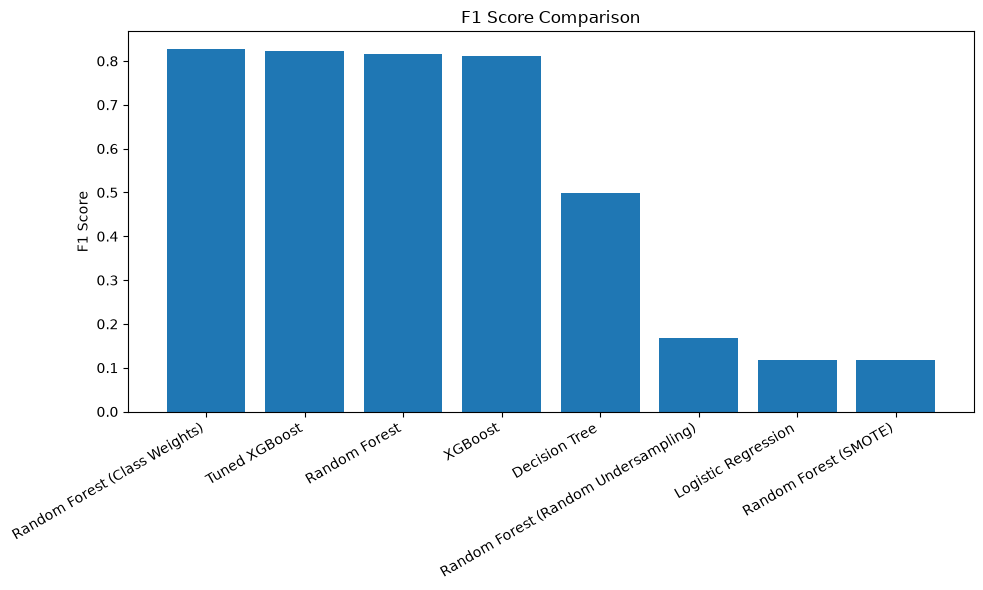

In [81]:
plt.figure(figsize=(10,6))

plt.bar(
    comparison["Model"],
    comparison["F1 Score"]
)

plt.xticks(rotation=30, ha="right")

plt.ylabel("F1 Score")

plt.title("F1 Score Comparison")

plt.tight_layout()

plt.savefig(
    "../artifacts/plots/model_f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## ROC-AUC Comparison

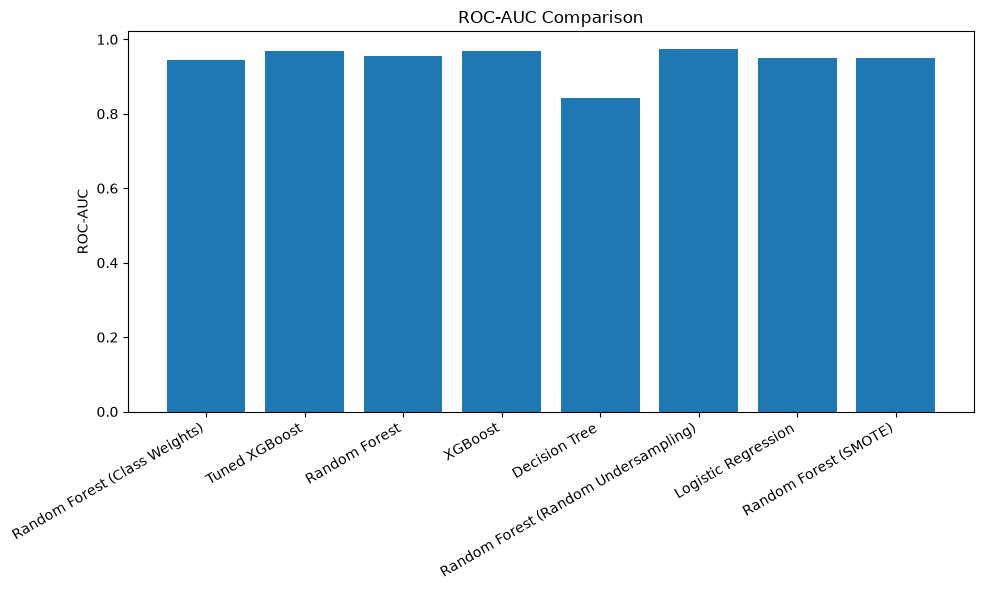

In [82]:
plt.figure(figsize=(10,6))

plt.bar(
    comparison["Model"],
    comparison["ROC-AUC"]
)

plt.xticks(rotation=30, ha="right")

plt.ylabel("ROC-AUC")

plt.title("ROC-AUC Comparison")

plt.tight_layout()

plt.savefig(
    "../artifacts/plots/model_roc_auc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Overall Score

In [83]:
comparison["Overall Score"] = (
    comparison["Precision"] +
    comparison["Recall"] +
    comparison["F1 Score"] +
    comparison["ROC-AUC"]
) / 4

comparison = comparison.sort_values(
    by="Overall Score",
    ascending=False
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overall Score
0,Random Forest (Class Weights),0.999489,0.958333,0.726316,0.826347,0.943893,0.863722
1,Tuned XGBoost,0.999436,0.870588,0.778947,0.822222,0.968960,0.860180
2,Random Forest,0.999436,0.898734,0.747368,0.816092,0.954520,0.854179
3,XGBoost,0.999366,0.810526,0.810526,0.810526,0.967861,0.849860
4,Decision Tree,0.997691,0.391566,0.684211,0.498084,0.841214,0.603769
5,Random Forest (Random Undersampling),0.985603,0.092551,0.863158,0.167176,0.972907,0.523948
6,Logistic Regression,0.978377,0.063272,0.863158,0.117901,0.950620,0.498738
7,Random Forest (SMOTE),0.978377,0.063272,0.863158,0.117901,0.950620,0.498738


## Overall Ranking Plot

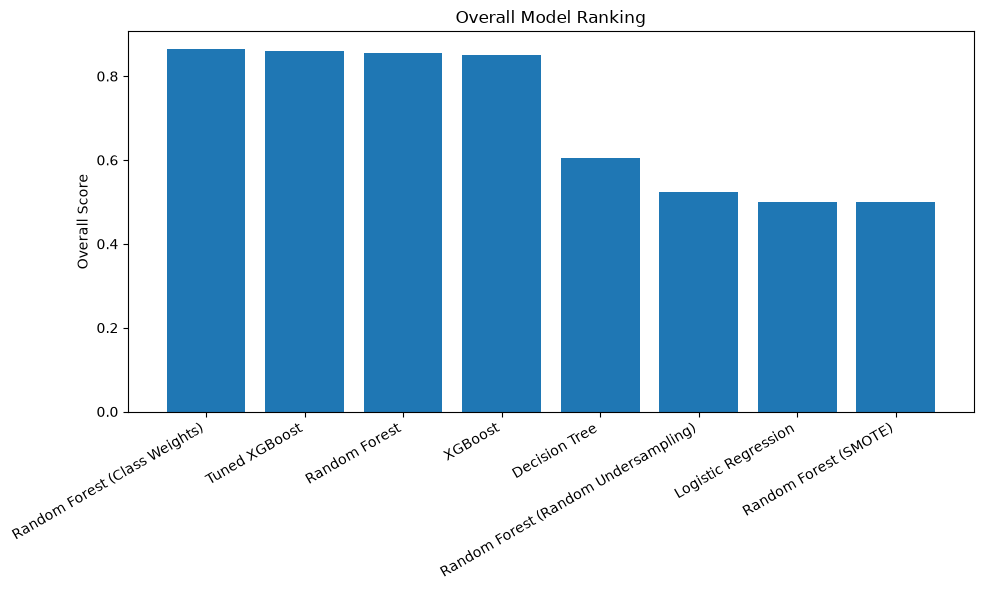

In [84]:
plt.figure(figsize=(10,6))

plt.bar(
    comparison["Model"],
    comparison["Overall Score"]
)

plt.xticks(rotation=30, ha="right")

plt.ylabel("Overall Score")

plt.title("Overall Model Ranking")

plt.tight_layout()

plt.savefig(
    "../artifacts/plots/final_model_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Save Final Ranking

In [85]:
comparison.to_csv(
    "../results/final_model_ranking.csv",
    index=False
)

print("Final ranking saved.")

Final ranking saved.


## Final Recommendation

In [86]:
best = comparison.iloc[0]

print("="*70)
print("FINAL RECOMMENDATION")
print("="*70)

print(f"""
Best Model      : {best['Model']}
Accuracy        : {best['Accuracy']:.4f}
Precision       : {best['Precision']:.4f}
Recall          : {best['Recall']:.4f}
F1 Score        : {best['F1 Score']:.4f}
ROC-AUC         : {best['ROC-AUC']:.4f}
Overall Score   : {best['Overall Score']:.4f}
""")

print("Recommendation:")
print("Random Forest with Class Weights is recommended for deployment because it achieved the highest F1 Score while maintaining excellent precision, high accuracy, and strong ROC-AUC performance.")

FINAL RECOMMENDATION

Best Model      : Random Forest (Class Weights)
Accuracy        : 0.9995
Precision       : 0.9583
Recall          : 0.7263
F1 Score        : 0.8263
ROC-AUC         : 0.9439
Overall Score   : 0.8637

Recommendation:
Random Forest with Class Weights is recommended for deployment because it achieved the highest F1 Score while maintaining excellent precision, high accuracy, and strong ROC-AUC performance.
